In [ ]:
!pip -q install transformers torch torchvision pillow matplotlib timm

In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image
from google.colab import files
from transformers import Owlv2Processor, Owlv2ForObjectDetection

In [ ]:
if torch.cuda.is_available():
    print("GPU is available")
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is NOT available. Running on CPU")

GPU is available
GPU name: Tesla T4


Saving computer.jfif to computer.jfif
image size: (500, 257)


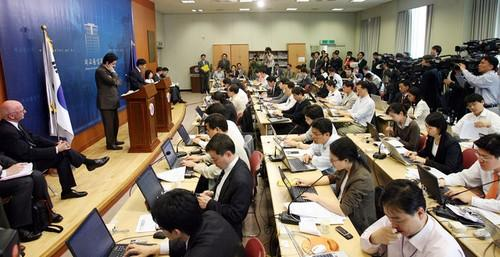

In [ ]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

print("image size:", image.size)
image

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [ ]:
model_name = "google/owlv2-base-patch16-ensemble"

processor = Owlv2Processor.from_pretrained(model_name)
model = Owlv2ForObjectDetection.from_pretrained(model_name).to(device)

print("OWLv2 loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

The image processor of type `Owlv2ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/620M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/418 [00:00<?, ?it/s]

OWLv2 loaded.


In [ ]:
texts = [["laptop"]]
detection_threshold = 0.40

In [ ]:
inputs = processor(
    text=texts,
    images=image,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

In [ ]:
target_sizes = torch.tensor([image.size[::-1]]).to(device)  # (height, width)

results = processor.post_process_grounded_object_detection(
    outputs=outputs,
    target_sizes=target_sizes,
    threshold=detection_threshold,
    text_labels=texts
)

result = results[0]
boxes = result["boxes"].cpu()
scores = result["scores"].cpu()
labels = result["text_labels"]

print("Detected objects:")
for box, score, label in zip(boxes, scores, labels):
    print(f"{label}: score={score:.3f}, box={box.tolist()}")

Detected objects:
laptop: score=0.478, box=[194.7861785888672, 106.17668914794922, 205.32913208007812, 118.78878021240234]
laptop: score=0.440, box=[326.2843322753906, 105.26936340332031, 346.8017272949219, 117.892333984375]
laptop: score=0.477, box=[265.0122985839844, 106.00352478027344, 290.0896301269531, 121.78753662109375]
laptop: score=0.437, box=[365.8690185546875, 121.16624450683594, 379.9357604980469, 142.07000732421875]
laptop: score=0.700, box=[176.9645233154297, 123.79762268066406, 202.4145965576172, 146.61416625976562]
laptop: score=0.577, box=[272.133544921875, 134.26902770996094, 300.73443603515625, 151.774169921875]
laptop: score=0.589, box=[382.5028991699219, 140.290771484375, 418.12701416015625, 166.8120880126953]
laptop: score=0.705, box=[160.40423583984375, 138.1654052734375, 196.10061645507812, 169.36485290527344]
laptop: score=0.504, box=[276.55950927734375, 141.32501220703125, 315.9198913574219, 170.8990478515625]
laptop: score=0.407, box=[280.2486572265625, 153.6

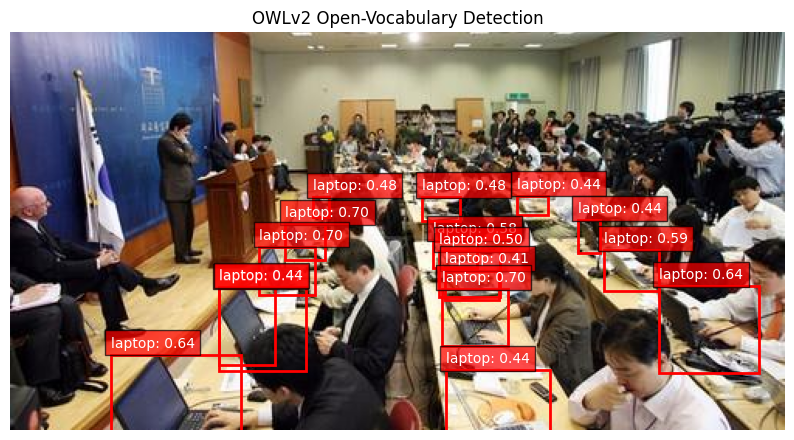

In [ ]:
fig, ax = plt.subplots(1, figsize=(10, 8))
ax.imshow(image)

for box, score, label in zip(boxes, scores, labels):
    x1, y1, x2, y2 = box.tolist()
    w, h = x2 - x1, y2 - y1

    rect = patches.Rectangle(
        (x1, y1), w, h,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)

    ax.text(
        x1,
        max(0, y1 - 5),
        f"{label}: {score:.2f}",
        color="white",
        fontsize=10,
        bbox=dict(facecolor="red", alpha=0.7)
    )

ax.set_title("OWLv2 Open-Vocabulary Detection")
ax.axis("off")
plt.show()